In [132]:
import os
import re
import torch 
import pandas as pd
import numpy as np
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, MinMaxScaler
import torch.optim as optim
from scipy.signal import welch
from scipy.stats import entropy
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

In [133]:
# Analyzing dataset
dataset = "./Dataset"
dataset_actions = {}

for root, dirs, files in os.walk(dataset):
    for file in files:
        file = file[:-4]
        action =  re.sub(r'\d+$', '', file)
        if action not in dataset_actions:
            dataset_actions[action] = 1
        else:
            dataset_actions[action] += 1

Dataset_actions_log = "Dataset Actions Count\n"
total = 0
for key, value in dataset_actions.items():
    total += value
    Dataset_actions_log += f"{key}: {value} | "
Dataset_actions_log += f"total: {total}"
print(Dataset_actions_log)

Dataset Actions Count
final: 175 | grenade: 195 | idle: 21 | reload: 172 | shield: 195 | total: 758


In [134]:
# Read in dataset into a dataframe of 7 columns, 6 measurement columns, 1 label
# each row has 6 lists, 1 label corresponding to 1 file
dataset = "./Dataset"
dataset_pd = pd.DataFrame(columns=["x_acc", "y_acc", "z_acc", "x_gyro", "y_gyro", "z_gyro", "action"])

for root, dirs, files in os.walk(dataset):
    for file in files:
        if 'idle' not in file:
            file_path = os.path.join(root, file)
            file_pd = pd.read_csv(file_path)
            x_acc = file_pd.iloc[:, 0].tolist()
            y_acc = file_pd.iloc[:, 1].tolist()
            z_acc = file_pd.iloc[:, 2].tolist()
            x_gyro = file_pd.iloc[:, 3].tolist()
            y_gyro = file_pd.iloc[:, 4].tolist()
            z_gyro = file_pd.iloc[:, 5].tolist()
            file = file[:-4]
            action =  re.sub(r'\d+$', '', file)
            row = {"x_acc": x_acc, "y_acc": y_acc, "z_acc": z_acc, "x_gyro": x_gyro, "y_gyro": y_gyro, "z_gyro": z_gyro, "action": action}
            dataset_pd = pd.concat([dataset_pd, pd.DataFrame([row])], ignore_index=True)
        else: 
            for chunk_idle in pd.read_csv(os.path.join(root, file), chunksize=200): # take idle at 200 row max length
                x_acc = chunk_idle.iloc[:, 0].tolist()
                y_acc = chunk_idle.iloc[:, 1].tolist()
                z_acc = chunk_idle.iloc[:, 2].tolist()
                x_gyro = chunk_idle.iloc[:, 3].tolist()
                y_gyro = chunk_idle.iloc[:, 4].tolist()
                z_gyro = chunk_idle.iloc[:, 5].tolist()
                file = file[:-4]
                action =  re.sub(r'\d+$', '', file)
                row = {"x_acc": x_acc, "y_acc": y_acc, "z_acc": z_acc, "x_gyro": x_gyro, "y_gyro": y_gyro, "z_gyro": z_gyro, "action": 'idle'}
                dataset_pd = pd.concat([dataset_pd, pd.DataFrame([row])], ignore_index=True)


In [135]:
print(dataset_pd.shape)

(855, 7)


In [136]:
# Extract all features (can be removed later)
# time domain: mean, std, rms, min, max, median, 25th percentile, 50th percentile, 75th percentile, 
# zero-crossing rate, peak count
# frequency domain: mean, max, Spectral Entropy, total power, Spectral centroid, DC component, 
# Dominant frequency, Power Spectral Density, average energy per coefficient 

all_features = pd.DataFrame()
for i in range(len(dataset_pd.index)):
    data_dict = {}
    label = dataset_pd.iloc[i, len(dataset_pd.columns)-1]
    for j in range(len(dataset_pd.columns)-1):
        col_name = dataset_pd.columns[j]
        data = dataset_pd.iloc[i, j]
        # Compute time-domain features
        t_mean = np.mean(data)
        t_std_deviation = np.std(data)
        t_rms = np.sqrt(np.mean(np.square(data)))
        t_min = np.min(data)
        t_max = np.max(data)
        t_median = np.median(data)
        t_25_q = np.percentile(data, 25)
        t_50_q = np.percentile(data, 50)
        t_75_q = np.percentile(data, 75)
        t_zero_crossing = np.sum(np.diff(np.sign(data)) != 0)
        t_peaks = len(np.where((np.diff(np.sign(np.diff(data)))) < 0)[0])

        # Compute frequency-domain features
        freq_domain = np.fft.rfft(data)
        f_mean = abs(np.mean(freq_domain))
        f_max = abs(max(freq_domain))
        f_spectral_entropy = entropy(np.abs(freq_domain))
        f_total_power = np.sum(np.abs(freq_domain) ** 2)
        f_spectral_centroid = np.sum(np.arange(len(freq_domain)) * np.abs(freq_domain)) / np.sum(np.abs(freq_domain))
        f_DC_component = abs(freq_domain[0])
        f_dominant_frequency = np.argmax(np.abs(freq_domain))
        f_PSD = welch(data)[1]
        f_average_E_per_coeff = f_total_power / len(freq_domain)

        # Create dictionary
        data_dict.update({
            f"t_mean_{col_name}": t_mean,
            f"t_std_deviation_{col_name}": t_std_deviation,
            f"t_rms_{col_name}": t_rms,
            #f"t_min_{col_name}": t_min,
            #f"t_max_{col_name}": t_max,
            #f"t_median_{col_name}": t_median,
            #f"t_25_q_{col_name}": t_25_q,
            #f"t_50_q_{col_name}": t_50_q,
            f"t_75_q_{col_name}": t_75_q,
            #f"t_zero_crossing_{col_name}": t_zero_crossing,
            #f"t_peaks_{col_name}": t_peaks,
            #"freq_domain": freq_domain,
            f"f_mean_{col_name}": f_mean,
            f"f_max_{col_name}": f_max,
            #f"f_spectral_entropy_{col_name}": f_spectral_entropy,
            #f"f_total_power_{col_name}": f_total_power,
            f"f_spectral_centroid_{col_name}": f_spectral_centroid,
            #"f_DC_component": f_DC_component,
            #f"f_dominant_frequency_{col_name}": f_dominant_frequency,
            #"f_PSD": f_PSD,
            f"f_average_E_per_coeff_{col_name}": f_average_E_per_coeff,
        })
    data_dict.update({f"label": label})
    
    all_features = pd.concat([all_features, pd.DataFrame([data_dict])], ignore_index=True)

all_features.to_csv("extracted_feature_with_label.csv", index=False)

label_encoder = LabelEncoder()
all_features['label'] = label_encoder.fit_transform(all_features['label'])
for label, encoded_label in zip(label_encoder.classes_, label_encoder.transform(label_encoder.classes_)):
    print(f"{label}: {encoded_label}")

print(all_features.shape)

final: 0
grenade: 1
idle: 2
reload: 3
shield: 4
(855, 49)


In [137]:
class Sample_NN(nn.Module):
    def __init__(self):
        super().__init__()
        self.fc1 = nn.Linear(48, 24)  # Input layer: 6 neurons, Hidden Layer: 4 neurons
        self.fc2 = nn.Linear(24, 12)  # Hidden layer: 4 neurons, Output Layer: 2 neurons
        self.fc3 = nn.Linear(12, 5)


    def forward(self, x):
        m = nn.ReLU()
        x = self.fc1(x)
        x = m(x)
        intermediate_1 = x
        x = self.fc2(x)
        x = m(x)
        intermediate_2 = x
        x = self.fc3(x)
        intermediate_3 = x
        output = F.softmax(x, dim=1)  # dimension 1: softmax function applied along second dimension of the tensor
        return output, intermediate_1, intermediate_2, intermediate_3

In [138]:
class Sample_NN_dataset(Dataset):
    def __init__(self, all_features):
        # preprocessing done here
        self.data = all_features
        self.labels = self.data['label']
        self.data = self.data.drop(columns=['label'])
        # L2 Normalisation for each column
        self.data = self.data / np.linalg.norm(self.data, axis=0)
        # Scale to same range
        scaler = StandardScaler()
        scaled_data = scaler.fit_transform(self.data)
        min_max_scaler = MinMaxScaler(feature_range=(0, 1))
        scaled_min_max_data = min_max_scaler.fit_transform(scaled_data)
        self.data = pd.DataFrame(scaled_min_max_data, columns=self.data.columns)
        self.data.to_csv("extracted_feature_scaled_norm.csv", index=False)

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        features = torch.tensor(self.data.iloc[idx].values, dtype=torch.float)
        label = torch.tensor(self.labels[idx], dtype=torch.long)  # Assuming labels are integers
        return features, label


In [139]:
dataset = Sample_NN_dataset(all_features)
train_data, test_data = train_test_split(dataset, test_size=0.25, random_state=1334)  # my favourite number
batch_size = 32
train_loader = DataLoader(train_data, batch_size=batch_size, shuffle=True)
test_loader = DataLoader(test_data, batch_size=batch_size, shuffle=False)
epochs = 100
model = Sample_NN()
optimizer = optim.SGD(model.parameters(), lr=0.1)
criterion = nn.CrossEntropyLoss()

for epoch in range(epochs):
    model.train()  # Sets the model to training mode
    for inputs, labels in train_loader:
        optimizer.zero_grad()  # Zero the gradients
        outputs, _ , _ , _  = model(inputs)  # Forward pass
        loss = criterion(outputs, labels)  # Calculate the loss
        loss.backward()  # Backward pass
        optimizer.step()  # Update weights

    model.eval()  # Sets the model to evaluation mode
    with torch.no_grad():  # Disable gradient calculation during testing
        correct = 0
        total = 0
        for inputs, labels in test_loader:
            outputs, _ , _ , _  = model(inputs)
            _, predicted = torch.max(outputs, 1)  # we dont need all the maximum of a tensor, hence _
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

    accuracy = correct / total

    print(f'Epoch [{epoch + 1}/{epochs}], Test Accuracy: {accuracy:.2%}')

Epoch [1/100], Test Accuracy: 20.56%
Epoch [2/100], Test Accuracy: 21.50%
Epoch [3/100], Test Accuracy: 24.30%
Epoch [4/100], Test Accuracy: 24.77%
Epoch [5/100], Test Accuracy: 24.77%
Epoch [6/100], Test Accuracy: 24.77%
Epoch [7/100], Test Accuracy: 24.77%
Epoch [8/100], Test Accuracy: 24.77%
Epoch [9/100], Test Accuracy: 24.77%
Epoch [10/100], Test Accuracy: 24.77%
Epoch [11/100], Test Accuracy: 26.17%
Epoch [12/100], Test Accuracy: 24.77%
Epoch [13/100], Test Accuracy: 29.91%
Epoch [14/100], Test Accuracy: 44.86%
Epoch [15/100], Test Accuracy: 47.20%
Epoch [16/100], Test Accuracy: 47.20%
Epoch [17/100], Test Accuracy: 46.26%
Epoch [18/100], Test Accuracy: 42.52%
Epoch [19/100], Test Accuracy: 34.58%
Epoch [20/100], Test Accuracy: 44.86%
Epoch [21/100], Test Accuracy: 35.98%
Epoch [22/100], Test Accuracy: 22.43%
Epoch [23/100], Test Accuracy: 22.43%
Epoch [24/100], Test Accuracy: 24.30%
Epoch [25/100], Test Accuracy: 41.12%
Epoch [26/100], Test Accuracy: 47.20%
Epoch [27/100], Test 

In [140]:
torch.save(model.state_dict(), 'model_weights_biases.pth')

In [141]:
model_weights_path = 'model_weights_biases.pth'
model.load_state_dict(torch.load(model_weights_path))
txt_path = 'model_parameters.txt'
with open(txt_path, 'w') as f:
    for name, param in model.named_parameters():
        f.write(f"{name}:\n")
        f.write(f"{param.tolist()}\n\n")

print("Model parameters saved to:", txt_path)



Model parameters saved to: model_parameters.txt


In [142]:
ll = [0.273161657, 0.349160246, 0.6460988, 0.029122231, 0.444351266, 0.222782642, 0.207148008, 0.505886584, 0.675018485, 0.803802681, 0.715239157, 0.627961515, 0.519162049, 0.363436466, 0.456383583, 0.276303229, 0.480240993, 0.615752692, 0.557788426, 0.416374069, 0.199555895, 0.430981913, 0.317010201, 0.202329882, 0.300134831, 0.417119658, 0.420197452, 0.058340637, 0.396209448, 0.31648072, 0.262195599, 0.120288609, 0.474086501, 0.515329753, 0.4924506, 0.295636998, 0.213328683, 0.290823809, 0.201122114, 0.183861975, 0.577980726, 0.552382407, 0.532900758, 0.276554743, 0.195396682, 0.54918847, 0.195891168, 0.246948337]
tensor2 = torch.Tensor([ll, ll,ll, ll,ll, ll,ll, ll,ll, ll,ll, ll,ll, ll,ll, ll, ll, ll,ll, ll,ll, ll,ll, ll,ll, ll,ll, ll,ll, ll,ll, ll])

output, one, two, three = model(tensor2)
print(f"output: {output}")
print(f"one: {one}")
print(f"two: {two}")
print(f"three: {three}")

output: tensor([[9.9960e-01, 2.8860e-04, 1.8557e-05, 1.6509e-07, 9.0332e-05],
        [9.9960e-01, 2.8860e-04, 1.8557e-05, 1.6509e-07, 9.0332e-05],
        [9.9960e-01, 2.8860e-04, 1.8557e-05, 1.6509e-07, 9.0332e-05],
        [9.9960e-01, 2.8860e-04, 1.8557e-05, 1.6509e-07, 9.0332e-05],
        [9.9960e-01, 2.8860e-04, 1.8557e-05, 1.6509e-07, 9.0332e-05],
        [9.9960e-01, 2.8860e-04, 1.8557e-05, 1.6509e-07, 9.0332e-05],
        [9.9960e-01, 2.8860e-04, 1.8557e-05, 1.6509e-07, 9.0332e-05],
        [9.9960e-01, 2.8860e-04, 1.8557e-05, 1.6509e-07, 9.0332e-05],
        [9.9960e-01, 2.8860e-04, 1.8557e-05, 1.6509e-07, 9.0332e-05],
        [9.9960e-01, 2.8860e-04, 1.8557e-05, 1.6509e-07, 9.0332e-05],
        [9.9960e-01, 2.8860e-04, 1.8557e-05, 1.6509e-07, 9.0332e-05],
        [9.9960e-01, 2.8860e-04, 1.8557e-05, 1.6509e-07, 9.0332e-05],
        [9.9960e-01, 2.8860e-04, 1.8557e-05, 1.6509e-07, 9.0332e-05],
        [9.9960e-01, 2.8860e-04, 1.8557e-05, 1.6509e-07, 9.0332e-05],
        [9.9

7
Input size: torch.Size([32, 48])
tensor([[0.3682, 0.4072, 0.5905,  ..., 0.3339, 0.2054, 0.2829],
        [0.7332, 0.6501, 0.4630,  ..., 0.1739, 0.1622, 0.3909],
        [0.4307, 0.1626, 0.4735,  ..., 0.7532, 0.2511, 0.2469],
        ...,
        [0.6917, 0.3451, 0.3186,  ..., 0.3233, 0.2335, 0.2362],
        [0.6153, 0.2961, 0.3581,  ..., 0.1569, 0.1674, 0.1443],
        [0.5234, 0.1987, 0.4041,  ..., 0.2521, 0.2290, 0.1829]])
tensor([[0.6599, 0.5156, 0.4263,  ..., 0.5789, 0.1936, 0.4785],
        [0.5004, 0.0761, 0.4043,  ..., 0.1550, 0.3191, 0.0399],
        [0.1206, 0.6152, 0.8629,  ..., 0.5209, 0.2205, 0.5408],
        ...,
        [0.6603, 0.5310, 0.4347,  ..., 0.5199, 0.2441, 0.7565],
        [0.6487, 0.6656, 0.5240,  ..., 0.2417, 0.2583, 0.2511],
        [0.6830, 0.1525, 0.2632,  ..., 0.3229, 0.3307, 0.1205]])
tensor([[0.5405, 0.5155, 0.5093,  ..., 0.6908, 0.4896, 0.7959],
        [0.8989, 0.4043, 0.2030,  ..., 0.5182, 0.3488, 0.1875],
        [0.5725, 0.2749, 0.3848,  ..., 0.

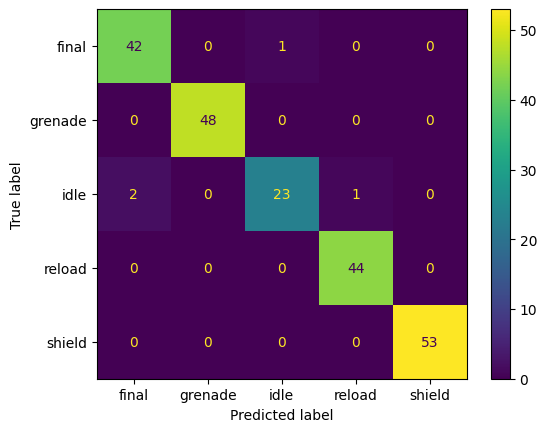

: 

In [143]:
true_labels = []
predicted_labels = []

print(len(test_loader))
inputs, _ = next(iter(test_loader))

# Print the shape of the input tensor
print("Input size:", inputs.size())


for inputs, labels in test_loader:
    print(inputs)
    outputs, _, _, _ = model(inputs)
    _, predicted = torch.max(outputs, 1)
    true_labels.extend(labels.numpy())
    predicted_labels.extend(predicted.numpy())

true_labels = np.array(true_labels)
predicted_labels = np.array(predicted_labels)

conf_matrix = confusion_matrix(true_labels, predicted_labels)

print("Confusion Matrix:")
print(conf_matrix)
cm_display = ConfusionMatrixDisplay(conf_matrix, display_labels = ["final", "grenade", "idle", "reload", "shield"])
cm_display.plot()
plt.show()
